# Lung Cancer Histopathology Classification (DenseNet-169, PyTorch)

In [14]:
import os, time, math, random
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from torchvision import models
from torchinfo import summary
from tqdm import tqdm
from PIL import Image
from concurrent.futures import ThreadPoolExecutor
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if hasattr(torch, "xpu") and torch.xpu.is_available():
    torch.xpu.manual_seed_all(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if hasattr(torch, "xpu") and torch.xpu.is_available():
    device = torch.device("xpu")
    device_name = torch.xpu.get_device_name(0)
elif torch.cuda.is_available():
    device = torch.device("cuda")
    device_name = torch.cuda.get_device_name(0)
else:
    device = torch.device("cpu")
    device_name = ""
print("PyTorch:", torch.__version__)
print("Compute device:", device, device_name)
if device.type == "cpu":
    print("WARNING: No GPU backend is active. Restart this notebook kernel and select the Python environment with torch XPU support.")

USE_AMP = device.type in ("cuda", "xpu")

def gpu_memory_gb(peak=False):
    if device.type == "xpu":
        getter = torch.xpu.max_memory_allocated if peak else torch.xpu.memory_allocated
    elif device.type == "cuda":
        getter = torch.cuda.max_memory_allocated if peak else torch.cuda.memory_allocated
    else:
        return 0.0
    return getter() / (1024 ** 3)

IMG = 224
CLASSES = ["adenocarcinoma", "squamous_cell_carcinoma", "benign"]
MEAN = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
STD = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)

PyTorch: 2.14.1+xpu
Compute device: xpu Intel(R) Arc(TM) A750 Graphics


In [15]:
DATA_DIR = os.path.join(os.getcwd(), "data")
if not os.path.isdir(DATA_DIR):
    raise FileNotFoundError(f"Dataset folder not found: {DATA_DIR}")
print("Using dataset:", DATA_DIR)

Using dataset: c:\Users\User\Desktop\Thesis\data


In [16]:
IMG_EXT = (".jpeg", ".jpg", ".png", ".bmp", ".tif", ".tiff")

def map_class(name):
    n = name.lower()
    if "aca" in n or "adeno" in n: return 0
    if "scc" in n or "squam" in n: return 1
    if "benign" in n or n in ("n", "lung_n") or n.endswith("_n"): return 2
    return None

def collect(root):
    paths, labels = [], []
    for r, _, fs in os.walk(root):
        if "__MACOSX" in r: continue
        for f in fs:
            if f.lower().endswith(IMG_EXT) and not f.startswith("."):
                p = os.path.join(r, f)
                lab = None
                for part in reversed(os.path.relpath(p, root).split(os.sep)[:-1]):
                    lab = map_class(part)
                    if lab is not None: break
                paths.append(p); labels.append(lab)
    return paths, labels

def load_image(p):
    # same preprocessing for train, validation and the 198 test images
    im = Image.open(p)
    im.draft("RGB", (IMG * 2, IMG * 2))
    return np.asarray(im.convert("RGB").resize((IMG, IMG), Image.BILINEAR), dtype=np.uint8)

def load_all(paths):
    with ThreadPoolExecutor(max_workers=4) as ex:
        return np.stack(list(ex.map(load_image, paths)))

paths, labels = collect(DATA_DIR)
keep = [i for i, l in enumerate(labels) if l is not None]
paths = [paths[i] for i in keep]; labels = np.array([labels[i] for i in keep])
print("Images:", len(paths), {CLASSES[c]: int((labels == c).sum()) for c in range(3)})

t0 = time.time()
X = torch.from_numpy(load_all(paths))
y = torch.from_numpy(labels).long()
print("Loaded", tuple(X.shape), f"in {time.time()-t0:.0f}s")

Images: 15000 {'adenocarcinoma': 5000, 'squamous_cell_carcinoma': 5000, 'benign': 5000}
Loaded (15000, 224, 224, 3) in 28s


In [17]:
import csv

holdout_rng = np.random.default_rng(SEED)
holdout_parts = []
for class_id, class_name in enumerate(CLASSES):
    candidates = sorted(
        np.flatnonzero(labels == class_id),
        key=lambda image_idx: paths[image_idx],
    )
    if len(candidates) < 100:
        raise ValueError(f"Need at least 100 images for {class_name}; found {len(candidates)}")
    holdout_parts.extend(holdout_rng.choice(candidates, size=100, replace=False))

holdout_idx = np.asarray(sorted(holdout_parts, key=lambda image_idx: paths[image_idx]), dtype=int)
holdout_set = set(holdout_idx.tolist())
development_idx = np.asarray(
    sorted((image_idx for image_idx in range(len(y)) if image_idx not in holdout_set),
           key=lambda image_idx: paths[image_idx]),
    dtype=int,
)
tr_idx, tmp_idx = train_test_split(
    development_idx, test_size=0.2, stratify=labels[development_idx], random_state=SEED
)
va_idx, te_idx = train_test_split(
    tmp_idx, test_size=0.5, stratify=labels[tmp_idx], random_state=SEED
)

assert len(holdout_idx) == 300
assert np.bincount(labels[holdout_idx], minlength=len(CLASSES)).tolist() == [100, 100, 100]
assert not (set(tr_idx) | set(va_idx) | set(te_idx)) & holdout_set
assert len(tr_idx) + len(va_idx) + len(te_idx) + len(holdout_idx) == len(y)

HOLDOUT_MANIFEST = os.path.join(os.getcwd(), "holdout_300_manifest.csv")
with open(HOLDOUT_MANIFEST, "w", newline="", encoding="utf-8") as manifest_file:
    writer = csv.writer(manifest_file)
    writer.writerow(("image_path", "true_class"))
    writer.writerows(
        (os.path.relpath(paths[image_idx], DATA_DIR), CLASSES[labels[image_idx]])
        for image_idx in holdout_idx
    )

print("Reserved final holdout:", len(holdout_idx),
      {CLASSES[class_id]: int((labels[holdout_idx] == class_id).sum()) for class_id in range(3)})
print("Train/Val/Internal Test:", len(tr_idx), len(va_idx), len(te_idx))
print("Saved holdout manifest:", HOLDOUT_MANIFEST)

def to_input(xb):
    return xb.to(device, non_blocking=True).permute(0, 3, 1, 2).float().div_(255)

def augment(x):
    B = x.size(0)
    m = (torch.rand(B, 1, 1, 1, device=device) < 0.5)
    x = torch.where(m, x.flip(3), x)
    m = (torch.rand(B, 1, 1, 1, device=device) < 0.5)
    x = torch.where(m, x.flip(2), x)
    x = torch.rot90(x, random.randint(0, 3), (2, 3))
    x = x * (1 + (torch.rand(B, 1, 1, 1, device=device) - 0.5) * 0.3)
    x = x * (1 + (torch.rand(B, 3, 1, 1, device=device) - 0.5) * 0.15)
    mean = x.mean((1, 2, 3), keepdim=True)
    x = (x - mean) * (1 + (torch.rand(B, 1, 1, 1, device=device) - 0.5) * 0.3) + mean
    return x.clamp_(0, 1)

def normalize(x):
    return ((x - MEAN) / STD).contiguous(memory_format=torch.channels_last)

Reserved final holdout: 300 {'adenocarcinoma': 100, 'squamous_cell_carcinoma': 100, 'benign': 100}
Train/Val/Internal Test: 11760 1470 1470
Saved holdout manifest: c:\Users\User\Desktop\Thesis\holdout_300_manifest.csv


In [18]:
model = models.densenet169(weights=models.DenseNet169_Weights.IMAGENET1K_V1)
model.classifier = nn.Sequential(nn.Dropout(0.4), nn.Linear(model.classifier.in_features, 3))
model = model.to(device).to(memory_format=torch.channels_last)
print("Parameters (M):", sum(p.numel() for p in model.parameters()) / 1e6)
print("Model summary:")
print(summary(
    model,
    input_size=(1, 3, IMG, IMG),
    device=device,
    depth=2,
    col_names=("input_size", "output_size", "num_params", "trainable"),
    verbose=0,
))

EPOCHS, BATCH, LR, WD, WARMUP_EPOCHS, PATIENCE = 15, 32, 2e-4, 0.05, 1, 4
MODEL_PATH = os.path.join(os.getcwd(), "best_model.pt")

decay, no_decay = [], []
for n_, p in model.named_parameters():
    (no_decay if p.ndim <= 1 else decay).append(p)
optimizer = torch.optim.AdamW(
    [{"params": decay, "weight_decay": WD}, {"params": no_decay, "weight_decay": 0.0}], lr=LR)

steps_per_epoch = math.ceil(len(tr_idx) / BATCH)
total_steps, warmup_steps = EPOCHS * steps_per_epoch, WARMUP_EPOCHS * steps_per_epoch
def lr_lambda(step):
    if step < warmup_steps: return (step + 1) / warmup_steps
    prog = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return max(0.01, 0.5 * (1 + math.cos(math.pi * prog)))
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scaler = torch.amp.GradScaler("cuda", enabled=device.type == "cuda")

@torch.no_grad()
def evaluate(indices):
    model.eval()
    loss_sum, preds = 0.0, []
    for i in range(0, len(indices), 64):
        b = indices[i:i + 64]
        xb = normalize(to_input(X[b])); yb = y[b].to(device)
        with torch.autocast(device.type, enabled=USE_AMP):
            out = model(xb)
        loss_sum += F.cross_entropy(out, yb, reduction="sum").item()
        preds.append(out.argmax(1).cpu())
    preds = torch.cat(preds).numpy()
    return loss_sum / len(indices), preds, y[indices].numpy()

Parameters (M): 12.489475
Model summary:
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
DenseNet                                 [1, 3, 224, 224]          [1, 3]                    --                        True
├─Sequential: 1-1                        [1, 3, 224, 224]          [1, 1664, 7, 7]           --                        True
│    └─Conv2d: 2-1                       [1, 3, 224, 224]          [1, 64, 112, 112]         9,408                     True
│    └─BatchNorm2d: 2-2                  [1, 64, 112, 112]         [1, 64, 112, 112]         128                       True
│    └─ReLU: 2-3                         [1, 64, 112, 112]         [1, 64, 112, 112]         --                        --
│    └─MaxPool2d: 2-4                    [1, 64, 112, 112]         [1, 64, 56, 56]           --                        --
│    └─_DenseBlock: 2-5                  [1, 64, 56, 56]           [1, 256, 56, 56]       

In [19]:
history = {
    "train_loss": [], "train_accuracy": [],
    "val_loss": [], "val_accuracy": [],
    "epoch_seconds": [], "gpu_peak_memory_gb": [],
}
best_acc, best_loss, bad = 0.0, 1e9, 0
for epoch in range(EPOCHS):
    model.train(); t0 = time.time()
    if device.type == "xpu":
        torch.xpu.reset_peak_memory_stats()
    elif device.type == "cuda":
        torch.cuda.reset_peak_memory_stats()
    perm = np.random.permutation(tr_idx)
    run_loss, correct = 0.0, 0
    batches = tqdm(range(0, len(perm), BATCH), desc=f"Epoch {epoch+1}/{EPOCHS}", unit="batch")
    for i in batches:
        b = perm[i:i + BATCH]
        xb = normalize(augment(to_input(X[b]))); yb = y[b].to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device.type, enabled=USE_AMP):
            out = model(xb); loss = criterion(out, yb)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update(); scheduler.step()
        run_loss += loss.item() * len(b); correct += (out.argmax(1) == yb).sum().item()
        seen = min(i + len(b), len(perm))
        gpu_status = f"{gpu_memory_gb():.2f} GB" if device.type != "cpu" else "CPU"
        batches.set_postfix(loss=f"{run_loss/seen:.4f}", acc=f"{correct/seen:.3f}", gpu_mem=gpu_status)

    val_loss, vp, vl = evaluate(va_idx)
    val_acc = accuracy_score(vl, vp)
    epoch_seconds = time.time() - t0
    history["train_loss"].append(run_loss / len(perm))
    history["train_accuracy"].append(correct / len(perm))
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)
    history["epoch_seconds"].append(epoch_seconds)
    history["gpu_peak_memory_gb"].append(gpu_memory_gb(peak=True))
    tqdm.write(
        f"Epoch {epoch+1:02d}/{EPOCHS} | train loss {run_loss/len(perm):.4f} "
        f"acc {correct/len(perm):.4f} | val loss {val_loss:.4f} acc {val_acc:.4f} | "
        f"lr {scheduler.get_last_lr()[0]:.2e} | {epoch_seconds:.0f}s | "
        f"GPU peak {history['gpu_peak_memory_gb'][-1]:.2f} GB"
    )

    if val_acc > best_acc or (val_acc == best_acc and val_loss < best_loss):
        best_acc, best_loss, bad = val_acc, val_loss, 0
        torch.save(model.state_dict(), MODEL_PATH)
    else:
        bad += 1
        if bad >= PATIENCE:
            print("Early stopping"); break

print("Best val acc:", best_acc)
print("Best model saved to:", MODEL_PATH)

Epoch 1/15: 100%|██████████| 368/368 [02:04<00:00,  2.96batch/s, acc=0.922, gpu_mem=0.20 GB, loss=0.4430]


Epoch 01/15 | train loss 0.4430 acc 0.9218 | val loss 0.0898 acc 0.9871 | lr 2.00e-04 | 137s | GPU peak 2.59 GB


Epoch 2/15: 100%|██████████| 368/368 [01:49<00:00,  3.37batch/s, acc=0.981, gpu_mem=0.20 GB, loss=0.3404]


Epoch 02/15 | train loss 0.3404 acc 0.9815 | val loss 0.0844 acc 0.9925 | lr 1.97e-04 | 113s | GPU peak 2.59 GB


Epoch 3/15: 100%|██████████| 368/368 [01:49<00:00,  3.35batch/s, acc=0.991, gpu_mem=0.20 GB, loss=0.3181]


...

Epoch 13/15 | train loss 0.2927 acc 1.0000 | val loss 0.0753 acc 1.0000 | lr 9.90e-06 | 115s | GPU peak 2.59 GB


Epoch 14/15: 100%|██████████| 368/368 [01:50<00:00,  3.32batch/s, acc=1.000, gpu_mem=0.20 GB, loss=0.2929]


Epoch 14/15 | train loss 0.2929 acc 1.0000 | val loss 0.0795 acc 1.0000 | lr 2.51e-06 | 115s | GPU peak 2.59 GB


Epoch 15/15: 100%|██████████| 368/368 [01:51<00:00,  3.31batch/s, acc=1.000, gpu_mem=0.20 GB, loss=0.2930]


Epoch 15/15 | train loss 0.2930 acc 0.9999 | val loss 0.0797 acc 1.0000 | lr 2.00e-06 | 115s | GPU peak 2.59 GB
Best val acc: 1.0
Best model saved to: c:\Users\User\Desktop\Thesis\best_model.pt


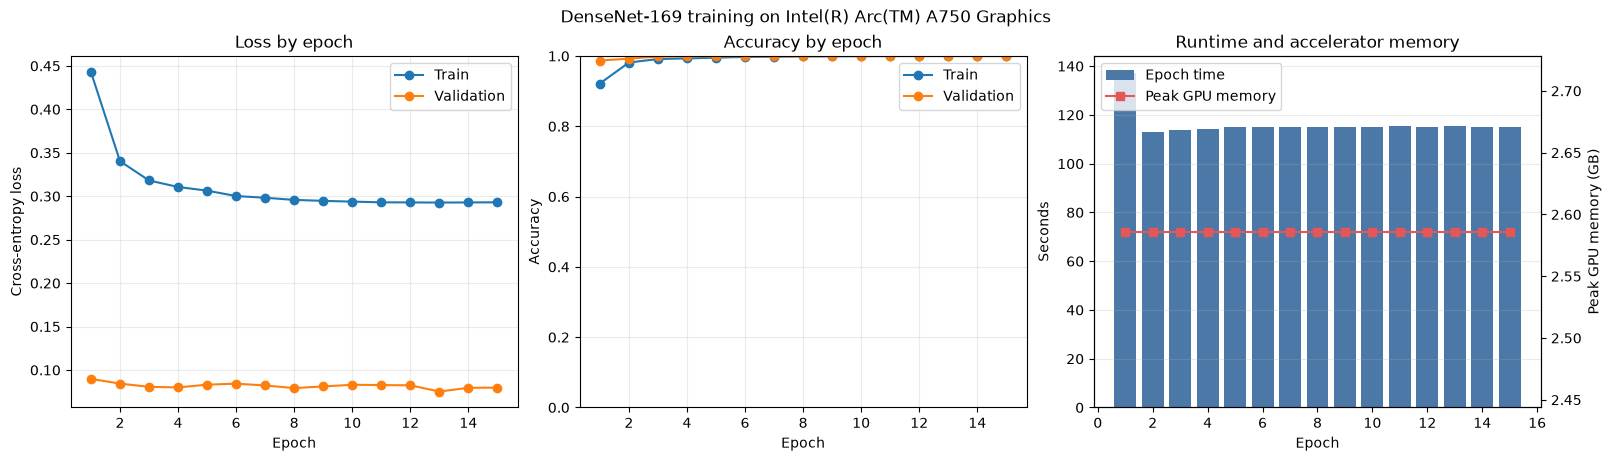

In [20]:
epochs_completed = np.arange(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), layout="constrained")

axes[0].plot(epochs_completed, history["train_loss"], marker="o", label="Train")
axes[0].plot(epochs_completed, history["val_loss"], marker="o", label="Validation")
axes[0].set(title="Loss by epoch", xlabel="Epoch", ylabel="Cross-entropy loss")
axes[0].grid(alpha=0.25); axes[0].legend()

axes[1].plot(epochs_completed, history["train_accuracy"], marker="o", label="Train")
axes[1].plot(epochs_completed, history["val_accuracy"], marker="o", label="Validation")
axes[1].set(title="Accuracy by epoch", xlabel="Epoch", ylabel="Accuracy", ylim=(0, 1))
axes[1].grid(alpha=0.25); axes[1].legend()

axes[2].bar(epochs_completed, history["epoch_seconds"], color="#4c78a8", label="Epoch time")
axes[2].set(title="Runtime and accelerator memory", xlabel="Epoch", ylabel="Seconds")
axes[2].grid(axis="y", alpha=0.25)
if device.type != "cpu":
    memory_axis = axes[2].twinx()
    memory_axis.plot(epochs_completed, history["gpu_peak_memory_gb"], color="#e45756", marker="s", label="Peak GPU memory")
    memory_axis.set_ylabel("Peak GPU memory (GB)")
    handles, labels_ = axes[2].get_legend_handles_labels()
    memory_handles, memory_labels = memory_axis.get_legend_handles_labels()
    axes[2].legend(handles + memory_handles, labels_ + memory_labels, loc="upper left")

fig.suptitle(f"DenseNet-169 training on {device_name}")
plt.show()

Internal test loss: 0.0752 | Internal test accuracy: 1.0000

Internal test report:
                         precision    recall  f1-score   support

         adenocarcinoma     1.0000    1.0000    1.0000       490
squamous_cell_carcinoma     1.0000    1.0000    1.0000       490
                 benign     1.0000    1.0000    1.0000       490

               accuracy                         1.0000      1470
              macro avg     1.0000    1.0000    1.0000      1470
           weighted avg     1.0000    1.0000    1.0000      1470



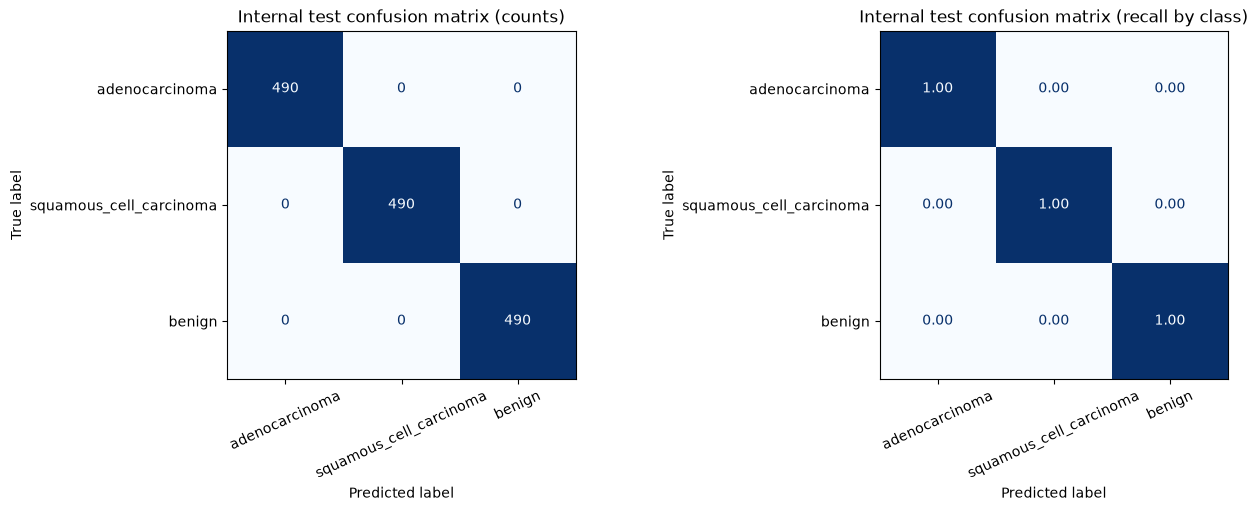

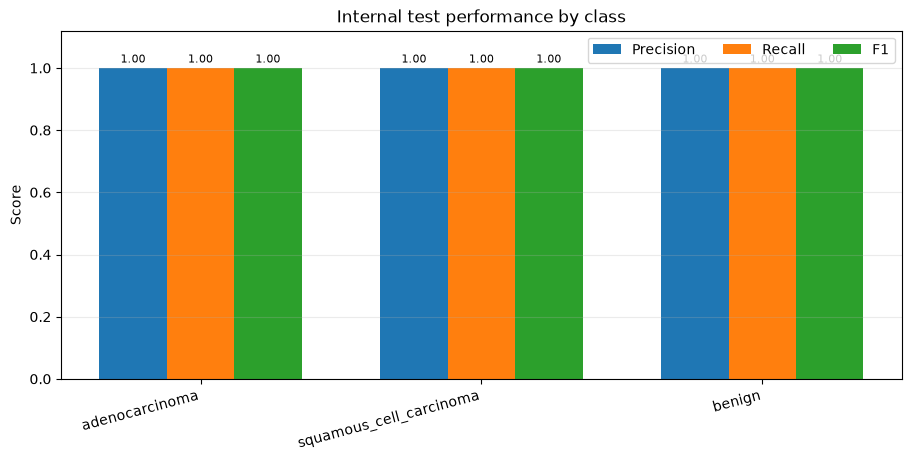

Final 300-image holdout: 100%|██████████| 5/5 [00:07<00:00,  1.49s/batch]


FINAL UNSEEN HOLDOUT: 300/300 correct, 0/300 incorrect | accuracy 100.0000% | loss 0.0754
Correct by class: {'adenocarcinoma': '100/100', 'squamous_cell_carcinoma': '100/100', 'benign': '100/100'}
                         precision    recall  f1-score   support

         adenocarcinoma     1.0000    1.0000    1.0000       100
squamous_cell_carcinoma     1.0000    1.0000    1.0000       100
                 benign     1.0000    1.0000    1.0000       100

               accuracy                         1.0000       300
              macro avg     1.0000    1.0000    1.0000       300
           weighted avg     1.0000    1.0000    1.0000       300



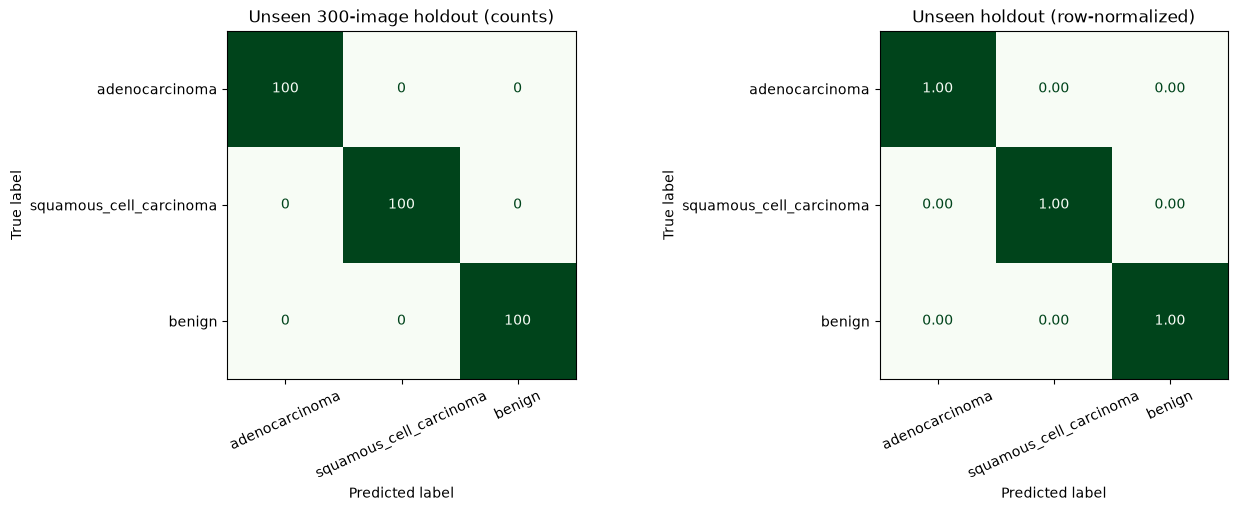

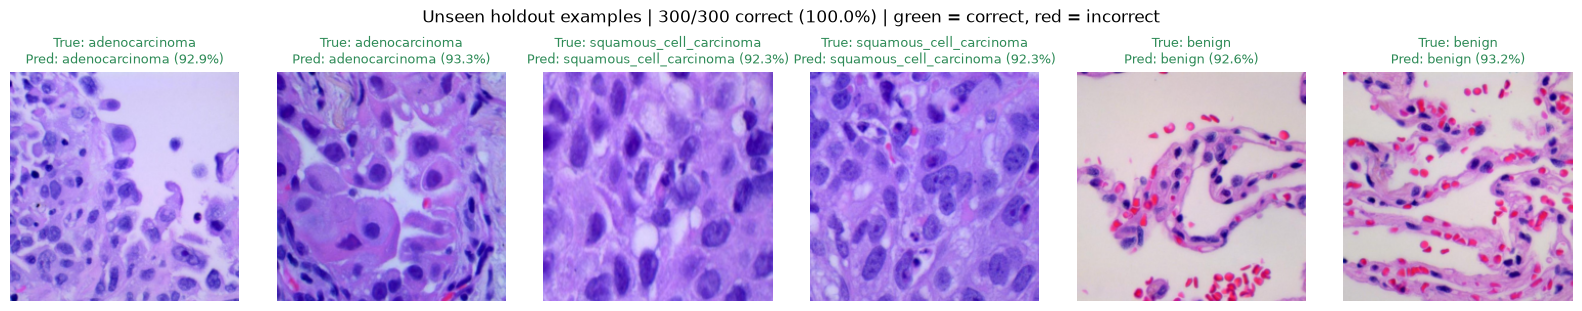

In [21]:
model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
test_loss, tp, tl = evaluate(te_idx)
print(f"Internal test loss: {test_loss:.4f} | Internal test accuracy: {accuracy_score(tl, tp):.4f}\n")
test_report = classification_report(
    tl, tp, target_names=CLASSES, digits=4, zero_division=0, output_dict=True
)
print("Internal test report:")
print(classification_report(tl, tp, target_names=CLASSES, digits=4, zero_division=0))

cm_counts = confusion_matrix(tl, tp, labels=np.arange(len(CLASSES)))
cm_normalized = confusion_matrix(tl, tp, labels=np.arange(len(CLASSES)), normalize="true")
fig, axes = plt.subplots(1, 2, figsize=(13, 5), layout="constrained")
ConfusionMatrixDisplay(cm_counts, display_labels=CLASSES).plot(
    ax=axes[0], cmap="Blues", colorbar=False, values_format="d", xticks_rotation=25
)
axes[0].set_title("Internal test confusion matrix (counts)")
ConfusionMatrixDisplay(cm_normalized, display_labels=CLASSES).plot(
    ax=axes[1], cmap="Blues", colorbar=False, values_format=".2f", xticks_rotation=25
)
axes[1].set_title("Internal test confusion matrix (recall by class)")
plt.show()

metric_names = ("precision", "recall", "f1-score")
metric_values = np.array([
    [test_report[class_name][metric] for metric in metric_names]
    for class_name in CLASSES
])
positions = np.arange(len(CLASSES))
bar_width = 0.24
fig, ax = plt.subplots(figsize=(9, 4.5), layout="constrained")
for metric_index, metric_name in enumerate(metric_names):
    bars = ax.bar(
        positions + (metric_index - 1) * bar_width,
        metric_values[:, metric_index],
        bar_width,
        label=metric_name.replace("-score", "").title(),
    )
    ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=8)
ax.set(title="Internal test performance by class", ylabel="Score", ylim=(0, 1.12))
ax.set_xticks(positions, CLASSES, rotation=15, ha="right")
ax.grid(axis="y", alpha=0.25); ax.legend(ncols=3)
plt.show()

assert not (set(holdout_idx) & (set(tr_idx) | set(va_idx) | set(te_idx)))
holdout_loss_sum, holdout_probabilities = 0.0, []
model.eval()
with torch.no_grad():
    for start in tqdm(range(0, len(holdout_idx), 64), desc="Final 300-image holdout", unit="batch"):
        batch_indices = holdout_idx[start:start + 64]
        xb = normalize(to_input(X[batch_indices]))
        yb = y[batch_indices].to(device)
        with torch.autocast(device.type, enabled=USE_AMP):
            logits = model(xb)
        holdout_loss_sum += F.cross_entropy(logits, yb, reduction="sum").item()
        holdout_probabilities.append(F.softmax(logits.float(), dim=1).cpu())

holdout_probabilities = torch.cat(holdout_probabilities).numpy()
holdout_predictions = holdout_probabilities.argmax(axis=1)
holdout_true = y[holdout_idx].numpy()
holdout_loss = holdout_loss_sum / len(holdout_idx)
holdout_correct = int((holdout_predictions == holdout_true).sum())
holdout_accuracy = holdout_correct / len(holdout_idx)
print(f"\nFINAL UNSEEN HOLDOUT: {holdout_correct}/300 correct, "
      f"{len(holdout_idx) - holdout_correct}/300 incorrect | "
      f"accuracy {holdout_accuracy:.4%} | loss {holdout_loss:.4f}")
print("Correct by class:", {
    CLASSES[class_id]: f"{int(((holdout_true == class_id) & (holdout_predictions == class_id)).sum())}/100"
    for class_id in range(len(CLASSES))
})
print(classification_report(
    holdout_true, holdout_predictions, labels=np.arange(len(CLASSES)),
    target_names=CLASSES, digits=4, zero_division=0,
))

holdout_cm = confusion_matrix(holdout_true, holdout_predictions, labels=np.arange(len(CLASSES)))
holdout_cm_normalized = confusion_matrix(
    holdout_true, holdout_predictions, labels=np.arange(len(CLASSES)), normalize="true"
)
fig, axes = plt.subplots(1, 2, figsize=(13, 5), layout="constrained")
ConfusionMatrixDisplay(holdout_cm, display_labels=CLASSES).plot(
    ax=axes[0], cmap="Greens", colorbar=False, values_format="d", xticks_rotation=25
)
axes[0].set_title("Unseen 300-image holdout (counts)")
ConfusionMatrixDisplay(holdout_cm_normalized, display_labels=CLASSES).plot(
    ax=axes[1], cmap="Greens", colorbar=False, values_format=".2f", xticks_rotation=25
)
axes[1].set_title("Unseen holdout (row-normalized)")
plt.show()

correct_examples = []
for class_id in range(len(CLASSES)):
    class_correct = np.flatnonzero((holdout_true == class_id) & (holdout_predictions == class_id))
    correct_examples.extend(class_correct[:2].tolist())
wrong_examples = np.flatnonzero(holdout_predictions != holdout_true)
visual_examples = correct_examples + wrong_examples[:12].tolist()
columns = 6
rows = math.ceil(len(visual_examples) / columns)
fig, axes = plt.subplots(rows, columns, figsize=(16, rows * 3), layout="constrained")
axes = np.asarray(axes).reshape(-1)
for ax, sample_idx in zip(axes, visual_examples):
    image = X[holdout_idx[sample_idx]].numpy()
    true_name = CLASSES[holdout_true[sample_idx]]
    predicted_name = CLASSES[holdout_predictions[sample_idx]]
    confidence = holdout_probabilities[sample_idx, holdout_predictions[sample_idx]]
    correct = holdout_predictions[sample_idx] == holdout_true[sample_idx]
    ax.imshow(image)
    ax.set_title(
        f"True: {true_name}\nPred: {predicted_name} ({confidence:.1%})",
        color="seagreen" if correct else "firebrick",
        fontsize=9,
    )
    ax.axis("off")
for ax in axes[len(visual_examples):]:
    ax.axis("off")
fig.suptitle(
    f"Unseen holdout examples | {holdout_correct}/300 correct "
    f"({holdout_accuracy:.1%}) | green = correct, red = incorrect"
)
plt.show()

In [22]:
EXTERNAL_TEST_DIR = os.path.join(os.getcwd(), "test_images")
if not os.path.isdir(EXTERNAL_TEST_DIR):
    print("Optional external test folder not found; skipping:", EXTERNAL_TEST_DIR)
else:
    tpaths, tlabels = collect(EXTERNAL_TEST_DIR)
    if not tpaths:
        print("No supported images found in:", EXTERNAL_TEST_DIR)
    else:
        print("External test images found:", len(tpaths))
        XT = torch.from_numpy(load_all(tpaths))
        model.eval(); probs = []
        with torch.no_grad():
            for i in range(0, len(XT), 64):
                xb = normalize(to_input(XT[i:i + 64]))
                with torch.autocast(device.type, enabled=USE_AMP):
                    probs.append(F.softmax(model(xb).float(), 1).cpu())
        probs = torch.cat(probs).numpy()
        pred = probs.argmax(1)

        print(f"\n{'File':45s} {'Prediction':26s} Confidence")
        for p, k, pr in zip(tpaths, pred, probs):
            print(f"{os.path.basename(p)[:44]:45s} {CLASSES[k]:26s} {pr[k]*100:.2f}%")

        print("\nPredicted counts:", {CLASSES[c]: int((pred == c).sum()) for c in range(3)})

        if all(l is not None for l in tlabels):
            tlabels = np.array(tlabels)
            print(f"\nExternal test accuracy: {accuracy_score(tlabels, pred):.4f}")
            print(classification_report(tlabels, pred, labels=[0, 1, 2], target_names=CLASSES, digits=4, zero_division=0))

Optional external test folder not found; skipping: c:\Users\User\Desktop\Thesis\test_images


Available online adenocarcinoma images: 5000
Available online squamous_cell_carcinoma images: 5000
Available online benign images: 5000


Downloaded prediction-only sample: 600 {'adenocarcinoma': 200, 'squamous_cell_carcinoma': 200, 'benign': 200}
External files: c:\Users\User\Desktop\Thesis\external_lc25000_sample
Source manifest: c:\Users\User\Desktop\Thesis\external_lc25000_manifest.csv
Source note: this is an LC25000 mirror, not an independent dataset.
Exact resized-image matches in the main dataset: 0/600


External prediction only: 100%|██████████| 10/10 [00:08<00:00,  1.17batch/s]


External mirror prediction result: 600/600 correct (100.00%); no training was performed on these files.
                         precision    recall  f1-score   support

         adenocarcinoma     1.0000    1.0000    1.0000       200
squamous_cell_carcinoma     1.0000    1.0000    1.0000       200
                 benign     1.0000    1.0000    1.0000       200

               accuracy                         1.0000       600
              macro avg     1.0000    1.0000    1.0000       600
           weighted avg     1.0000    1.0000    1.0000       600



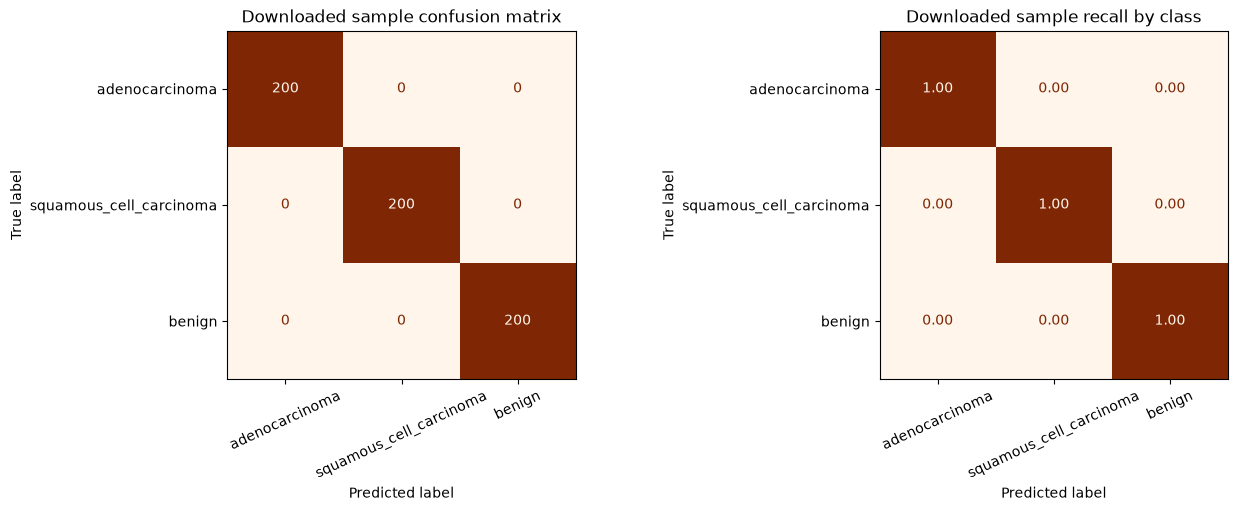

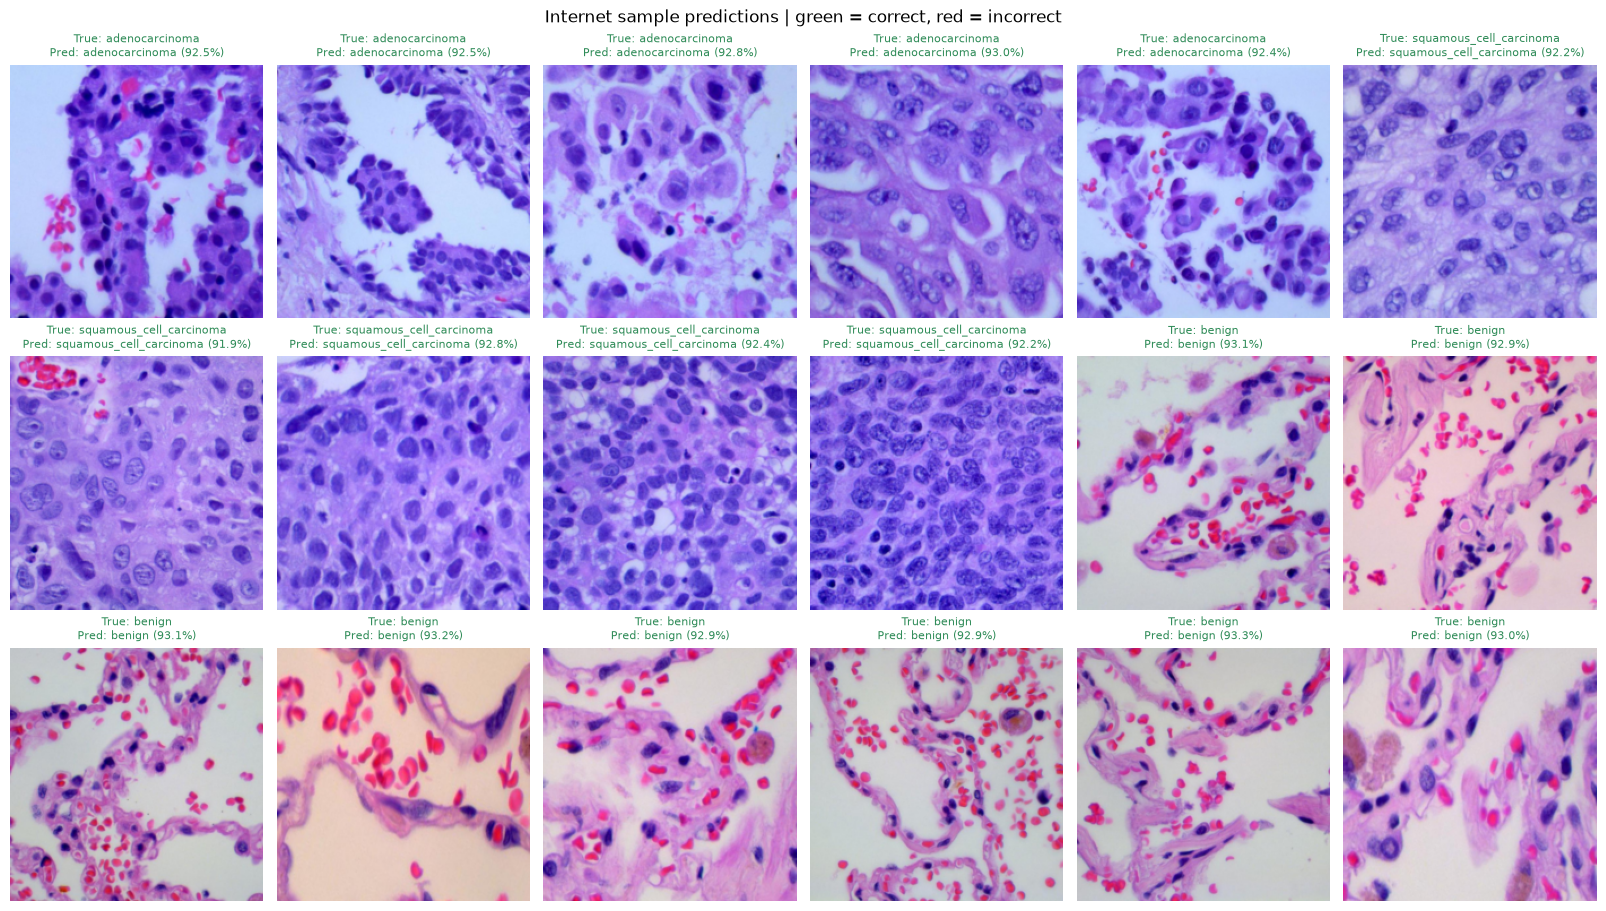

In [23]:
import csv
import hashlib
import json
import re
from urllib.parse import quote, urljoin
from urllib.request import Request, urlopen

EXTERNAL_REPO = "marlygotti/LC25000"
EXTERNAL_DIR = os.path.join(os.getcwd(), "external_lc25000_sample")
EXTERNAL_MANIFEST = os.path.join(os.getcwd(), "external_lc25000_manifest.csv")
SAMPLE_PER_CLASS = 200
request_headers = {"User-Agent": "DenseNet169-prediction-only/1.0"}

repo_api = f"https://huggingface.co/api/datasets/{EXTERNAL_REPO}"
with urlopen(Request(repo_api, headers=request_headers), timeout=30) as response:
    repo_revision = json.load(response)["sha"]

folder_to_class = {
    "lung_aca": CLASSES[0],
    "lung_scc": CLASSES[1],
    "lung_n": CLASSES[2],
}
external_files = {}
for source_folder in folder_to_class:
    next_url = (
        f"https://huggingface.co/api/datasets/{EXTERNAL_REPO}/tree/{repo_revision}/"
        f"{source_folder}?recursive=false&expand=false&limit=1000"
    )
    class_files = []
    while next_url:
        with urlopen(Request(next_url, headers=request_headers), timeout=30) as response:
            entries = json.load(response)
            link_header = response.headers.get("Link", "")
        class_files.extend(
            entry["path"] for entry in entries
            if entry.get("type") == "file" and entry["path"].lower().endswith(IMG_EXT)
        )
        next_match = re.search(r'<([^>]+)>\s*;\s*rel="next"', link_header)
        next_url = urljoin(next_url, next_match.group(1)) if next_match else None
    if len(class_files) < SAMPLE_PER_CLASS:
        raise ValueError(f"Only found {len(class_files)} files for {source_folder}")
    external_files[folder_to_class[source_folder]] = sorted(class_files)
    print(f"Available online {folder_to_class[source_folder]} images: {len(class_files)}")

sample_rng = random.Random(SEED + SAMPLE_PER_CLASS)
selected_files = []
for class_name in CLASSES:
    selected_files.extend(
        (class_name, source_path)
        for source_path in sample_rng.sample(external_files[class_name], SAMPLE_PER_CLASS)
    )

os.makedirs(EXTERNAL_DIR, exist_ok=True)
def download_external_image(record):
    class_name, source_path = record
    local_path = os.path.join(EXTERNAL_DIR, class_name, os.path.basename(source_path))
    os.makedirs(os.path.dirname(local_path), exist_ok=True)
    if not os.path.isfile(local_path) or os.path.getsize(local_path) == 0:
        file_url = (
            f"https://huggingface.co/datasets/{EXTERNAL_REPO}/resolve/"
            f"{repo_revision}/{quote(source_path, safe='/')}?download=true"
        )
        with urlopen(Request(file_url, headers=request_headers), timeout=60) as response:
            image_bytes = response.read()
        with open(local_path, "wb") as image_file:
            image_file.write(image_bytes)
    return class_name, source_path, local_path

with ThreadPoolExecutor(max_workers=8) as executor:
    downloaded_records = list(tqdm(
        executor.map(download_external_image, selected_files),
        total=len(selected_files),
        desc="Downloading external sample",
        unit="image",
    ))

with open(EXTERNAL_MANIFEST, "w", newline="", encoding="utf-8") as manifest_file:
    manifest_writer = csv.writer(manifest_file)
    manifest_writer.writerow(("local_path", "true_class", "source_repo", "source_revision", "source_path"))
    manifest_writer.writerows(
        (os.path.relpath(local_path, os.getcwd()), class_name, EXTERNAL_REPO, repo_revision, source_path)
        for class_name, source_path, local_path in downloaded_records
    )

external_paths = [local_path for _, _, local_path in downloaded_records]
external_labels = np.asarray([CLASSES.index(class_name) for class_name, _, _ in downloaded_records])
assert len(external_paths) == 600
assert np.bincount(external_labels, minlength=len(CLASSES)).tolist() == [200, 200, 200]
print("Downloaded prediction-only sample:", len(external_paths),
      {CLASSES[class_id]: int((external_labels == class_id).sum()) for class_id in range(len(CLASSES))})
print("External files:", EXTERNAL_DIR)
print("Source manifest:", EXTERNAL_MANIFEST)
print("Source note: this is an LC25000 mirror, not an independent dataset.")

external_images = torch.from_numpy(load_all(external_paths))
def image_fingerprint(image):
    return hashlib.sha256(memoryview(image)).digest()

local_fingerprints = {image_fingerprint(image) for image in X.numpy()}
external_fingerprints = [image_fingerprint(image) for image in external_images.numpy()]
exact_overlap = sum(fingerprint in local_fingerprints for fingerprint in external_fingerprints)
print(f"Exact resized-image matches in the main dataset: {exact_overlap}/600")
if exact_overlap:
    print("WARNING: matching source images are already in the main dataset; this score is a prediction smoke test, not independent validation.")

model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
model.eval()
external_probabilities = []
with torch.no_grad():
    for start in tqdm(range(0, len(external_images), 64), desc="External prediction only", unit="batch"):
        xb = normalize(to_input(external_images[start:start + 64]))
        with torch.autocast(device.type, enabled=USE_AMP):
            external_logits = model(xb)
        external_probabilities.append(F.softmax(external_logits.float(), dim=1).cpu())

external_probabilities = torch.cat(external_probabilities).numpy()
external_predictions = external_probabilities.argmax(axis=1)
external_correct = int((external_predictions == external_labels).sum())
external_accuracy = accuracy_score(external_labels, external_predictions)
print(f"\nExternal mirror prediction result: {external_correct}/600 correct "
      f"({external_accuracy:.2%}); no training was performed on these files.")
print(classification_report(
    external_labels, external_predictions, labels=np.arange(len(CLASSES)),
    target_names=CLASSES, digits=4, zero_division=0,
))

external_cm = confusion_matrix(external_labels, external_predictions, labels=np.arange(len(CLASSES)))
fig, axes = plt.subplots(1, 2, figsize=(13, 5), layout="constrained")
ConfusionMatrixDisplay(external_cm, display_labels=CLASSES).plot(
    ax=axes[0], cmap="Oranges", colorbar=False, values_format="d", xticks_rotation=25
)
axes[0].set_title("Downloaded sample confusion matrix")
external_cm_normalized = confusion_matrix(
    external_labels, external_predictions, labels=np.arange(len(CLASSES)), normalize="true"
)
ConfusionMatrixDisplay(external_cm_normalized, display_labels=CLASSES).plot(
    ax=axes[1], cmap="Oranges", colorbar=False, values_format=".2f", xticks_rotation=25
)
axes[1].set_title("Downloaded sample recall by class")
plt.show()

visual_rng = np.random.default_rng(SEED)
visual_indices = np.sort(visual_rng.choice(len(external_paths), size=18, replace=False))
fig, axes = plt.subplots(3, 6, figsize=(16, 9), layout="constrained")
for ax, sample_idx in zip(axes.flat, visual_indices):
    true_class = CLASSES[external_labels[sample_idx]]
    predicted_class = CLASSES[external_predictions[sample_idx]]
    confidence = external_probabilities[sample_idx, external_predictions[sample_idx]]
    is_correct = external_predictions[sample_idx] == external_labels[sample_idx]
    ax.imshow(external_images[sample_idx].numpy())
    ax.set_title(
        f"True: {true_class}\nPred: {predicted_class} ({confidence:.1%})",
        color="seagreen" if is_correct else "firebrick",
        fontsize=8,
    )
    ax.axis("off")
fig.suptitle("Internet sample predictions | green = correct, red = incorrect")
plt.show()